In [75]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as sns

#loading the current file
df = pd.read_pickle('data_frame.pkl')

In [ ]:
#AOV = Average order value
aov = df.groupby('InvoiceNo')['Revenue'].sum().mean().round(3)
print(f'AOV = ${aov}')

AOV = $401.596


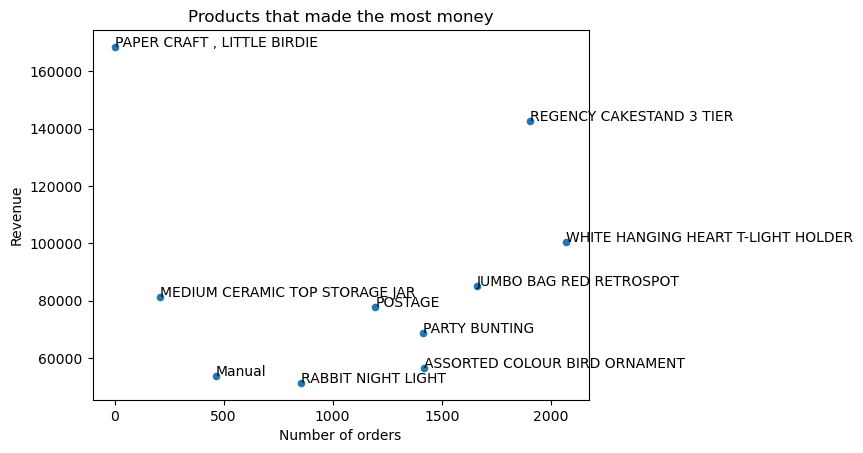

In [ ]:
#Items that made the most money
Money_makers = df.groupby('Description').agg({'InvoiceNo':'count','Revenue':'sum' }).sort_values(by=['Revenue','InvoiceNo'],ascending=False).head(10)
Money_makers.plot(kind='scatter',x='InvoiceNo',y='Revenue')

for i,txt in enumerate(Money_makers.index):
    plt.text(Money_makers.InvoiceNo.iloc[i], Money_makers.Revenue.iloc[i], txt)


plt.xlabel('Number of orders')
plt.ylabel('Revenue')
plt.title('Products that made the most money')
plt.show()


Text(0.5, 0, 'Sold Number')

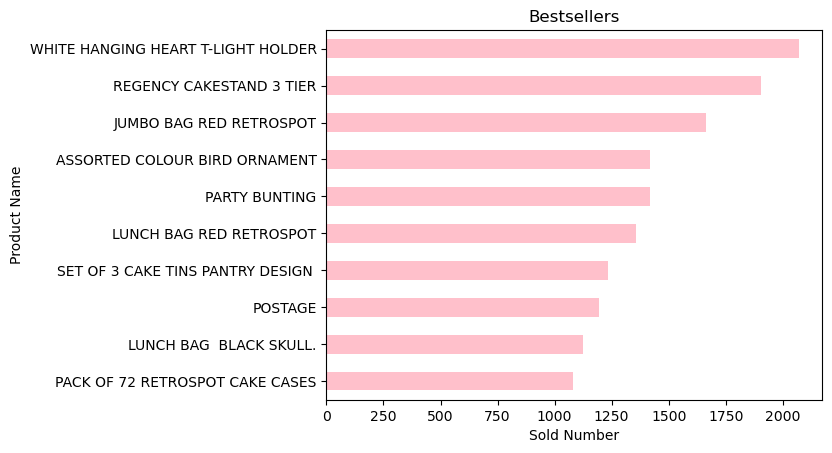

In [74]:
#Best sellers
Best_sellers = df.groupby('Description')['InvoiceNo'].count().sort_values().tail(10)
Best_sellers.plot(kind='barh',color='pink')
plt.title('Bestsellers')
plt.ylabel('Product Name')
plt.xlabel('Sold Number')



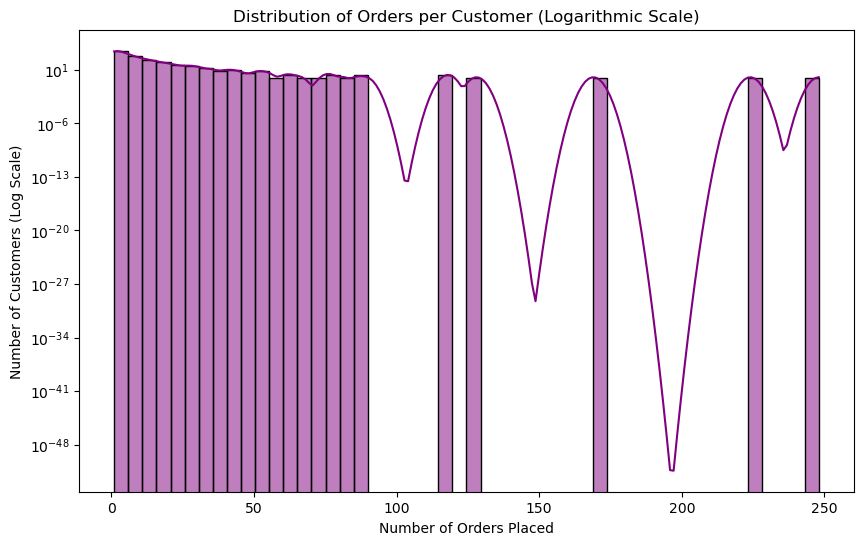

In [77]:
customers_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()
plt.figure(figsize=(10, 6))

sns.histplot(customers_orders, bins=50, kde=True, color='purple')

# logarytmic scale
plt.yscale('log')

plt.title('Distribution of Orders per Customer (Logarithmic Scale)')
plt.xlabel('Number of Orders Placed')
plt.ylabel('Number of Customers (Log Scale)')
plt.show()

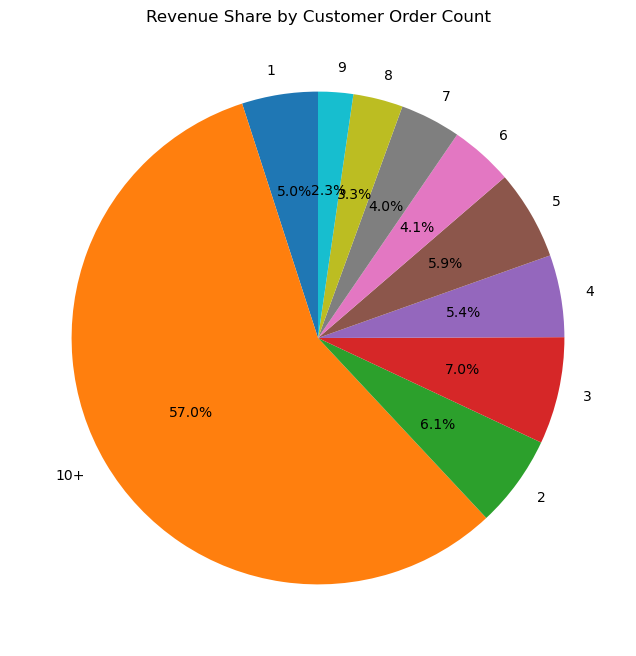

In [ ]:
#Which clients genrate the most income
client_summary = df.groupby('CustomerID').agg({'InvoiceNo':'nunique','Revenue':'sum'})
client_summary.InvoiceNo = client_summary.InvoiceNo.apply(lambda x:"10+" if x >= 10 else str(x))
client_summary2 = client_summary.groupby('InvoiceNo')['Revenue'].sum().reindex(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10+']).sort_index()

#Plotting
plt.figure(figsize=(8,8))
client_summary2.plot(kind='pie',startangle=90,autopct='%1.1f%%')
plt.title('Revenue Share by Customer Order Count')
plt.ylabel('')
plt.show()